In [1]:
%pip install grad-cam -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\ahmad\AppData\Local\Temp\ipykernel_18924\712943741.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(model_path, map_location=device)


[INFO] target layer: layer4.2.conv3


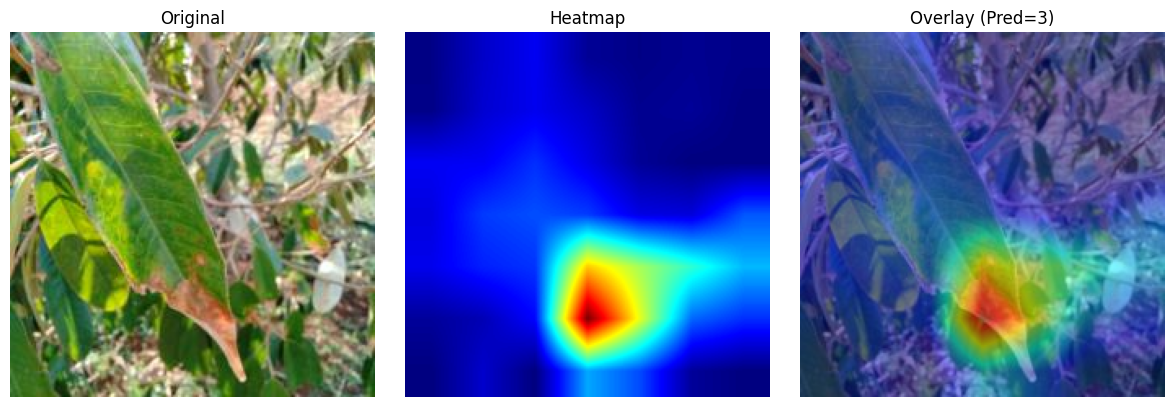

In [15]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ---------- CONFIG ----------
MODEL_PATH = "./transferLearning_aug/resnet50/resnet50_checkpoint_fold4.pt"
IMAGE_SIZE = (224, 224)
USE_GPU = torch.cuda.is_available()

# ---------- Helpers ----------
def load_model(model_path, device):
    obj = torch.load(model_path, map_location=device)
    if hasattr(obj, "module"):
        obj = obj.module
    obj.to(device)
    obj.eval()
    return obj

def find_last_conv_layer(model):
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
            last_name = name
    print(f"[INFO] target layer: {last_name}")
    return last_conv

def preprocess_img_pil(pil_img, size):
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    return transform(pil_img).unsqueeze(0)

def read_image_as_float(img_path, size):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((size[1], size[0]), Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

def gradcam_on_image(model, target_layer, img_path, device, class_idx=None):
    original = read_image_as_float(img_path, IMAGE_SIZE)
    pil = Image.open(img_path).convert("RGB")
    input_tensor = preprocess_img_pil(pil, IMAGE_SIZE).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        pred = outputs.argmax(dim=1).item()

    target = ClassifierOutputTarget(class_idx if class_idx is not None else pred)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[target])
    mask = grayscale_cam[0]

    cam_overlay = show_cam_on_image(original, mask, use_rgb=True)
    cam_mask_uint8 = (mask * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(cam_mask_uint8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return (original, heatmap, cam_overlay, pred)

# ---------- Run for selected images ----------
if __name__ == "__main__":
    device = torch.device("cuda" if USE_GPU else "cpu")
    model = load_model(MODEL_PATH, device)
    target_layer = find_last_conv_layer(model)

    # เลือก path รูปเอง
    selected_images = [
        "./data/test/LEAF_BLIGHT/to_label_2800.jpg",
    ]

    for img_path in selected_images:
        original, heatmap, overlay, pred = gradcam_on_image(model, target_layer, img_path, device)
        
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        ax[0].imshow(original)
        ax[0].set_title("Original")
        ax[1].imshow(heatmap)
        ax[1].set_title("Heatmap")
        ax[2].imshow(overlay)
        ax[2].set_title(f"Overlay (Pred={pred})")
        for a in ax: a.axis('off')
        plt.tight_layout()
        plt.show()
